# Assignment 1 - Building a Vision Model with Keras

In this assignment, you will build a simple vision model using Keras. The goal is to classify images from the Fashion MNIST dataset, which contains images of clothing items.

You will:
1. Load and inspect the Fashion MNIST dataset.
2. Run a simple baseline model to establish a performance benchmark.
3. Build and evaluate a simple CNN model, choosing appropriate loss and metrics.
4. Design and run controlled experiments on one hyperparameter (e.g., number of filters, kernel size, etc.) and one regularization technique (e.g., dropout, L2 regularization).
5. Analyze the results and visualize the model's performance.

# 1. Loading and Inspecting the Dataset

Fashion MNIST is a dataset of grayscale images of clothing items, with 10 classes. Each image is 28x28 pixels, like the MNIST dataset of handwritten digits. Keras provides a convenient way to load this dataset. 

In this section, you should:

- [V] Inspect the shapes of the training and test sets to confirm their size and structure.
- [V] Convert the labels to one-hot encoded format if necessary. (There is a utility function in Keras for this.)
- [V] Visualize a few images from the dataset to understand what the data looks like.

In [3]:
from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize the pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Classes in the Fashion MNIST dataset
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]  # this is a list 10 classes

In [4]:
# Inspect the shapes of the datasets
print(f"X_train: {type(X_train)}\ty_train: {type(y_train)}\tX_test: {type(X_test)}\t\ty_test: {type(y_test)}")
print(f"X_train: {X_train.shape}\t\ty_train: {y_train.shape}\t\t\tX_test: {X_test.shape}\t\t\ty_test: {y_test.shape}")
#print(f"Shape of one sample X: {X_train[0].shape}\tHow one sample X looks:\n {X_train[0]}")      # Shape of one sample: (28, 28)

# Check that actually we have 10 classes in train and test
import numpy as np
print(f"Number of classes y_train: {len(np.unique(y_train))}\tClasses y_train: {np.unique(y_train)}")
print(f"Number of classes y_test:  {len(np.unique(y_test))}\tClasses y_test:  {np.unique(y_test)}")

# Convert labels to one-hot encoding
from tensorflow.keras.utils import to_categorical
print(f'Before one-hot encoding: {y_train[0]}')
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)
print(f'After one-hot encoding: {y_train[0]}\tType: {type(y_train[0])}')

X_train: <class 'numpy.ndarray'>	y_train: <class 'numpy.ndarray'>	X_test: <class 'numpy.ndarray'>		y_test: <class 'numpy.ndarray'>
X_train: (60000, 28, 28)		y_train: (60000,)			X_test: (10000, 28, 28)			y_test: (10000,)
Number of classes y_train: 10	Classes y_train: [0 1 2 3 4 5 6 7 8 9]
Number of classes y_test:  10	Classes y_test:  [0 1 2 3 4 5 6 7 8 9]
Before one-hot encoding: 9
After one-hot encoding: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]	Type: <class 'numpy.ndarray'>


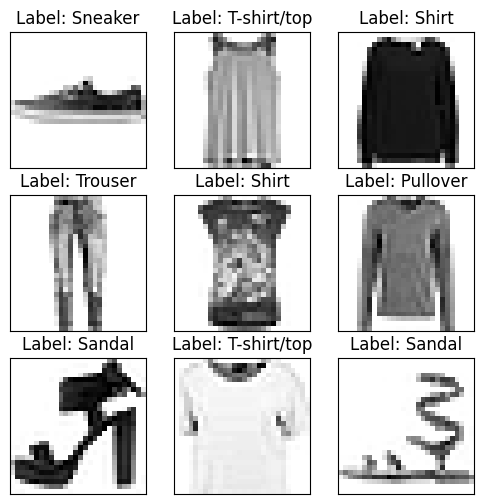

In [5]:
# Verify the data looks as expected

# Selecting 9 random indices
random_indices = np.random.choice(len(X_train), 9, replace=False)

# Creating a 3x3 grid plot
import matplotlib.pyplot as plt
fig, axes = plt.subplots(3, 3, figsize=(6, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[random_indices[i]], cmap=plt.cm.gray_r, interpolation='nearest')
    ax.set_title(f"Label: {class_names[np.argmax(y_train[random_indices[i]])]}")

    # Removing axis labels
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()

Reflection: Does the data look as expected? How is the quality of the images? Are there any issues with the dataset that you notice?

**Your answer here**: I did not have a specific expectation, it is cute, the images properly represent what it is intended, thus yes, as expected. The images are low resolution, still can be labeled. No specific issues, some observations, yes. Difference between Shirt and T-shirt/top looks challenging. Female open shoe is labelled as sandal, there is no closer label, this should be represent a challenge.

# 2. Baseline Model

In this section, you will create a linear regression model as a baseline. This model will not use any convolutional layers, but it will help you understand the performance of a simple model on this dataset.
You should:
- [V] Create a simple linear regression model using Keras.
- [V] Compile the model with an appropriate loss function and optimizer.
- [V] Train the model on the training set and evaluate it on the test set.

A linear regression model can be created using the `Sequential` API in Keras. Using a single `Dense` layer with no activation function is equivalent to a simple linear regression model. Make sure that the number of units in the output layer matches the number of classes in the dataset.

Note that for this step, we will need to use `Flatten` to convert the 2D images into 1D vectors before passing them to the model. Put a `Flatten()` layer as the first layer in your model so that the 2D image data can be flattened into 1D vectors.

In [6]:
# Setting a seed
import numpy as np
np.random.seed(31416)
import random
random.seed(31416)
import tensorflow.random as tf_random
tf_random.set_seed(31416)

In [5]:
from keras.models import Sequential
from keras.layers import Input, Flatten, Dense

# Create a simple linear regression model
model = Sequential()
# You can use `model.add(<layer>)` to add layers to the model
model.add(Input(shape=(28, 28)))                # layer with input 1 sample of X with shape (28, 28)
model.add(Flatten())                            # layer that flattens that sample to (, 784)
model.add(Dense(196, input_shape=(None, 784)))  # 196 neurons, activation=None or linear activation f(x) = x, input shape of (, 784)
model.add(Dense(98))                            #  98 neurons, activation=None or linear activation f(x) = x
model.add(Dense(10, activation='softmax'))      #  10 neurons matches number of classes, softmax activation
model.summary()
# Compile the model using `model.compile()`
model.compile(
    loss='categorical_crossentropy',    # Loss function
    optimizer='adam',                    # Optimizer
    metrics=['accuracy']                # Metrics to evaluate the model
)
# Train the model with `model.fit()`
model.fit(
    X_train, # Training data
    y_train, # Training labels
    epochs=5, # Number of epochs
    batch_size=32, # Number of samples per batch
    validation_split=0.2 # Use 20% of the data for validation
)
# Evaluate the model with `model.evaluate()`
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Loss:     {loss:.2f}')                      # Loss:     0.47 both
print(f'Accuracy: {accuracy*100:.2f}%')             # Accuracy: 83.23% SGD, 83.62% Adam

c:\miniconda3\envs\dsi_participant\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 196)            │       153,860 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 98)             │        19,306 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           990 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 174,156 (680.30 KB)

 Trainable params: 174,156 (680.30 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7684 - loss: 0.6591 - val_accuracy: 0.8382 - val_loss: 0.4941
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8288 - loss: 0.4928 - val_accuracy: 0.8434 - val_loss: 0.4686
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8368 - loss: 0.4661 - val_accuracy: 0.8468 - val_loss: 0.4547
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8436 - loss: 0.4501 - val_accuracy: 0.8468 - val_loss: 0.4478
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8471 - loss: 0.4393 - val_accuracy: 0.8470 - val_loss: 0.4445
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8397 - loss: 0.4656
Loss:     0.48
Accuracy: 83.51%


Reflection: What is the performance of the baseline model? How does it compare to what you expected? Why do you think the performance is at this level?

**Your answer here** Reasonable performance, I had no expectations. I played a bit with the size of layers, and SGD or Adam, and result is about the same. I think the non-linearity will help us capture some patterns we are not capturing now, and that it will improve performance, let's see.

# 3. Building and Evaluating a Simple CNN Model

In this section, you will build a simple Convolutional Neural Network (CNN) model using Keras. A convolutional neural network is a type of deep learning model that is particularly effective for image classification tasks. Unlike the basic neural networks we have built in the labs, CNNs can accept images as input without needing to flatten them into vectors.

You should:
- [ ] Build a simple CNN model with at least one convolutional layer (to learn spatial hierarchies in images) and one fully connected layer (to make predictions).
- [ ] Compile the model with an appropriate loss function and metrics for a multi-class classification problem.
- [ ] Train the model on the training set and evaluate it on the test set.

Convolutional layers are designed to accept inputs with three dimensions: height, width and channels (e.g., RGB for color images). For grayscale images like those in Fashion MNIST, the input shape will be (28, 28, 1).

When you progress from the convolutional layers to the fully connected layers, you will need to flatten the output of the convolutional layers. This can be done using the `Flatten` layer in Keras, which doesn't require any parameters.

In [6]:
from keras.layers import Conv2D, MaxPooling2D, Dropout, BatchNormalization

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Create a simple CNN model
model = Sequential()
model.add(Input(shape=(28, 28, 1)))                                                         # layer with input 1 sample of X with shape (28, 28, 1)
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))#, padding='same'))     # Convolutional layer
model.add(BatchNormalization())                                                             # Normalizes activations to stabilize and speed up training
model.add(MaxPooling2D(pool_size=(2, 2)))                                                   # Downsample to reduce spatial size
model.add(Dropout(0.25))                                                                    # Drop 25% of neurons
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))#, padding='same'))     # Convolutional layer
model.add(BatchNormalization())                                                             # Normalizes activations to stabilize and speed up training
model.add(MaxPooling2D(pool_size=(2, 2)))                                                   # Downsample to reduce spatial size
model.add(Dropout(0.25))                                                                    # Drop 25% of neurons
model.add(Flatten())                                                    # layer that flattens Features Map output to (, 784)
model.add(Dense(196, activation='relu'))                                # 196 neurons, activation = ReLU
model.add(Dense(98, activation='relu'))                                 #  98 neurons, activation = ReLU
model.add(Dense(10, activation='softmax'))                              #  10 neurons matches number of classes, softmax activation
model.summary()
# Compile the model using `model.compile()`
model.compile(
    loss='categorical_crossentropy',    # Loss function
    optimizer='adam',                    # Optimizer
    metrics=['accuracy']                # Metrics to evaluate the model
)
# Train the model
model.fit(
    X_train, # Training data
    y_train, # Training labels
    epochs=5, # Number of epochs
    batch_size=32, # Number of samples per batch
    validation_split=0.2 # Use 20% of the data for validation
)
# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Loss:     {loss:.2f}')                      # Loss:     0.28 filters=32,    without MaxPooling2D 0.34,      filters=64 0.28,     padding='same' 0.32,   batchNormalization 0.33,    DropOut 0.29
print(f'Accuracy: {accuracy*100:.2f}%')             # Accuracy: 89.70% filters=32,  without MaxPooling2D 89.44%     filters=64 89.83%,   padding='same' 89.54%, batchNormalization 88.84%,  DropOut 89.48%

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 196)            │       313,796 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 98)             │        19,306 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           990 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 372,172 (1.42 MB)

 Trainable params: 371,916 (1.42 MB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 72s 47ms/step - accuracy: 0.7913 - loss: 0.5914 - val_accuracy: 0.8816 - val_loss: 0.3172
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 67s 45ms/step - accuracy: 0.8805 - loss: 0.3237 - val_accuracy: 0.8877 - val_loss: 0.3057
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 67s 45ms/step - accuracy: 0.8956 - loss: 0.2835 - val_accuracy: 0.8938 - val_loss: 0.2897
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 67s 45ms/step - accuracy: 0.9052 - loss: 0.2542 - val_accuracy: 0.9029 - val_loss: 0.2579
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 68s 45ms/step - accuracy: 0.9135 - loss: 0.2314 - val_accuracy: 0.8948 - val_loss: 0.2842
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8908 - loss: 0.3115
Loss:     0.31
Accuracy: 89.13%


Reflection: Did the CNN model perform better than the baseline model? If so, by how much? What do you think contributed to this improvement?

Yes, it performed better, I will answer below. I played a bit with some parameters. By looking at training and validation results, I observe that batch normalization and dropout actually improved overfitting, even if the accuracy and loss in test dataset are a tad worse, I still would prefer to use them.

Baseline model performed 83.62% accuracy with 0.47 loss, and the CNN model performed 89.48% accuracy with 0.29 loss, which is a 7% improvement in accuracy and 38% reduction of loss.

To know what contributed this improvement, I just ran the Feature Maps layers with no activation on the Fully Connected layers, and I got 87.39% accuracy and 0.34 loss, improving the baseline. Then I run the baseline with activation='relu', and I got 86.55% accuracy and 0.37 loss, improving the baseline. Thus both non-linearity and convolutional layers contributed to this improvement.

# 4. Designing and Running Controlled Experiments

In this section, you will design and run controlled experiments to improve the model's performance. You will focus on one hyperparameter and one regularization technique.
You should:
- [V] Choose one hyperparameter to experiment with (e.g., number of filters, kernel size, number of layers, etc.) and one regularization technique (e.g., dropout, L2 regularization). For your hyperparameter, you should choose at least three different values to test (but there is no upper limit). For your regularization technique, simply test the presence or absence of the technique.
- [V Run experiments by modifying the model architecture or hyperparameters, and evaluate the performance of each model on the test set.
- [V] Record the results of your experiments, including the test accuracy and any other relevant metrics.
- [V] Visualize the results of your experiments using plots or tables to compare the performance of different models.

The best way to run your experiments is to create a `for` loop that iterates over a range of values for the hyperparameter you are testing. For example, if you are testing different numbers of filters, you can create a loop that runs the model with 32, 64, and 128 filters. Within the loop, you can compile and train the model, then evaluate it on the test set. After each iteration, you can store the results in a list or a dictionary for later analysis.

Note: It's critical that you re-initialize the model (by creating a new instance of the model) before each experiment. If you don't, the model will retain the weights from the previous experiment, which can lead to misleading results.

In [7]:
# A. Test Hyperparameters

results_f = {}
for filter in [32, 64, 128, 256]:
    # Create a simple CNN model
    model = Sequential()
    model.add(Input(shape=(28, 28, 1)))                                                         # layer with input 1 sample of X with shape (28, 28, 1)
    model.add(Conv2D(filters=filter, kernel_size=(3, 3), activation='relu', padding='same'))    # Convolutional layer
    model.add(BatchNormalization())                                                             # Normalizes activations to stabilize and speed up training
    model.add(MaxPooling2D(pool_size=(2, 2)))                                                   # Downsample to reduce spatial size
    model.add(Dropout(0.25))                                                                    # Drop 25% of neurons
    model.add(Conv2D(filters=filter, kernel_size=(3, 3), activation='relu', padding='same'))    # Convolutional layer
    model.add(BatchNormalization())                                                             # Normalizes activations to stabilize and speed up training
    model.add(MaxPooling2D(pool_size=(2, 2)))                                                   # Downsample to reduce spatial size
    model.add(Dropout(0.25))                                                                    # Drop 25% of neurons
    model.add(Flatten())                                                    # layer that flattens Features Map output to (, 784)
    model.add(Dense(196, activation='relu'))                                # 196 neurons, activation = ReLU
    model.add(Dense(98, activation='relu'))                                 #  98 neurons, activation = ReLU
    model.add(Dense(10, activation='softmax'))                              #  10 neurons matches number of classes, softmax activation
    model.summary()
    # Compile the model using `model.compile()`
    model.compile(
        loss='categorical_crossentropy',    # Loss function
        optimizer='adam',                    # Optimizer
        metrics=['accuracy']                # Metrics to evaluate the model
    )
    # Train the model
    model.fit(
        X_train, # Training data
        y_train, # Training labels
        epochs=5, # Number of epochs
        batch_size=32, # Number of samples per batch
        validation_split=0.2 # Use 20% of the data for validation
    )
    # Evaluate the model
    loss, accuracy = model.evaluate(X_test, y_test)
    results_f[filter] = (accuracy, loss)
    print(f'Loss:     {loss:.2f}')
    print(f'Accuracy: {accuracy*100:.2f}%')

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 196)            │       307,524 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 98)             │        19,306 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           990 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 337,644 (1.29 MB)

 Trainable params: 337,516 (1.29 MB)

 Non-trainable params: 128 (512.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 256)    │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 14, 14, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 14, 14, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 196)            │     2,458,820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 98)             │        19,306 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │           990 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,073,804 (11.73 MB)

 Trainable params: 3,072,780 (11.72 MB)

 Non-trainable params: 1,024 (4.00 KB)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 670s 445ms/step - accuracy: 0.7877 - loss: 0.6890 - val_accuracy: 0.8845 - val_loss: 0.3154
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 666s 444ms/step - accuracy: 0.8889 - loss: 0.3100 - val_accuracy: 0.8935 - val_loss: 0.3020
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 667s 445ms/step - accuracy: 0.9027 - loss: 0.2614 - val_accuracy: 0.8508 - val_loss: 0.3889
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 666s 444ms/step - accuracy: 0.9154 - loss: 0.2312 - val_accuracy: 0.8953 - val_loss: 0.2899
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 720s 469ms/step - accuracy: 0.9219 - loss: 0.2124 - val_accuracy: 0.8788 - val_loss: 0.3404
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 126ms/step - accuracy: 0.8696 - loss: 0.3691
Loss:     0.36
Accuracy: 87.19%


In [10]:
results_f

{32: (0.902999997138977, 0.2904607951641083),
 64: (0.8899999856948853, 0.3227311670780182),
 128: (0.9138000011444092, 0.2531951367855072),
 256: (0.8719000220298767, 0.3630475699901581)}

Experimenting with hyperparameter filter:

{32: (0.902999997138977, 0.2904607951641083),

 64: (0.8899999856948853, 0.3227311670780182),

 128: (0.9138000011444092, 0.2531951367855072),

 256: (0.8719000220298767, 0.3630475699901581)}

 Regularization through dropout of 25% of neurons was already in. Best result: filter=128

In [8]:
# B. Test presence or absence of regularization

from keras.regularizers import l2
# Define the regularization strength
results_L2 = {}
for l2_lambda in [0.1, 0.01, 0.001, 0.0001]:
    # Create a simple CNN model
    model = Sequential()
    model.add(Input(shape=(28, 28, 1)))                                                         # layer with input 1 sample of X with shape (28, 28, 1)
    model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu', kernel_regularizer=l2(l2_lambda), padding='same'))     # Convolutional layer
    model.add(BatchNormalization())                                                             # Normalizes activations to stabilize and speed up training
    model.add(MaxPooling2D(pool_size=(2, 2)))                                                   # Downsample to reduce spatial size                                                                # Drop 25% of neurons
    model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu', kernel_regularizer=l2(l2_lambda), padding='same'))     # Convolutional layer
    model.add(BatchNormalization())                                                             # Normalizes activations to stabilize and speed up training
    model.add(MaxPooling2D(pool_size=(2, 2)))                                                   # Downsample to reduce spatial size                                                                 # Drop 25% of neurons
    model.add(Flatten())                                                                        # layer that flattens Features Map output to (, 784)
    model.add(Dense(196, activation='relu', kernel_regularizer=l2(l2_lambda)))                  # 196 neurons, activation = ReLU
    model.add(BatchNormalization())
    model.add(Dense(98, activation='relu', kernel_regularizer=l2(l2_lambda)))                   #  98 neurons, activation = ReLU
    model.add(BatchNormalization())
    model.add(Dense(10, activation='softmax', kernel_regularizer=l2(l2_lambda)))                #  10 neurons matches number of classes, softmax activation
    model.summary()
    # Compile the model using `model.compile()`
    model.compile(
        loss='categorical_crossentropy',    # Loss function
        optimizer='adam',                    # Optimizer
        metrics=['accuracy']                # Metrics to evaluate the model
    )
    # Train the model
    model.fit(
        X_train, # Training data
        y_train, # Training labels
        epochs=5, # Number of epochs
        batch_size=32, # Number of samples per batch
        validation_split=0.2 # Use 20% of the data for validation
    )
    # Evaluate the model
    loss, accuracy = model.evaluate(X_test, y_test)
    results_L2[l2_lambda] = (accuracy, loss)
    print(f'Loss:     {loss:.2f}')                      # Loss:     0.40,       with L2 regularization: 
    print(f'Accuracy: {accuracy*100:.2f}%')             # Accuracy: 87.96%,     with L2 regularization: 



Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 196)            │       614,852 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 196)            │           784 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 98)             │        19,306 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 98)             │           392 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 10)             │           990 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 674,404 (2.57 MB)

 Trainable params: 673,560 (2.57 MB)

 Non-trainable params: 844 (3.30 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 196)            │       614,852 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 196)            │           784 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 98)             │        19,306 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 98)             │           392 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 10)             │           990 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 674,404 (2.57 MB)

 Trainable params: 673,560 (2.57 MB)

 Non-trainable params: 844 (3.30 KB)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 105s 68ms/step - accuracy: 0.8264 - loss: 0.5527 - val_accuracy: 0.8772 - val_loss: 0.4033
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 103s 69ms/step - accuracy: 0.9005 - loss: 0.3523 - val_accuracy: 0.8986 - val_loss: 0.3571
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 102s 68ms/step - accuracy: 0.9146 - loss: 0.3196 - val_accuracy: 0.8887 - val_loss: 0.3953
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 103s 69ms/step - accuracy: 0.9254 - loss: 0.2995 - val_accuracy: 0.8910 - val_loss: 0.4200
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 103s 69ms/step - accuracy: 0.9330 - loss: 0.2883 - val_accuracy: 0.8934 - val_loss: 0.4272
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8858 - loss: 0.4636
Loss:     0.45
Accuracy: 88.33%


In [9]:
results_L2

{0.1: (0.8432000279426575, 0.6636092662811279),
 0.01: (0.8694000244140625, 0.5372002124786377),
 0.001: (0.854200005531311, 0.5519477128982544),
 0.0001: (0.8833000063896179, 0.4545835852622986)}

Experimenting with regularization technique L2 regularization, filter = 64:

{0.1: (0.8432000279426575, 0.6636092662811279),

 0.01: (0.8694000244140625, 0.5372002124786377),

 0.001: (0.854200005531311, 0.5519477128982544),

 0.0001: (0.8833000063896179, 0.4545835852622986)}

 Best result, l2 = 0.0001. Still, all results are worse than filter = 64 and regularization through dropout of random 25% of neurons.

Reflection: Report on the performance of the models you tested. Did any of the changes you made improve the model's performance? If so, which ones? What do you think contributed to these improvements? Finally, what combination of hyperparameters and regularization techniques yielded the best performance?

Yes, using filter=128 improved the performance, brought accuracy beyond 91% and loss to 0.25. Having more filters could capture more subtleties and details in the local patterns. At the beginning of the models I created a seed to make results replicable. I just realized that I used dropout and did not set a seed there, I am not sure if the results are replicable now. Because these calculations take considerable amount of time in my overclocked 2011 CPU (no GPU involved), I will work with these results. The best performance is given with 128 filters and regularization through dropout 25% of the neurons. In part 3 I introduced dropout and kept it because the results at training and validation were more similars (less overfitting) than without it, and final accuracy and loss results on the test were same.

Final experimentations, let's fine tune the % of dropout, now with filter=128:

In [12]:
# A. Test Hyperparameters

results_d = {}
for dropout in [0, 0.05, 0.1, 0.15, 0.2, 0.3, 0.35]:
    # Create a simple CNN model
    model = Sequential()
    model.add(Input(shape=(28, 28, 1)))                                                         # layer with input 1 sample of X with shape (28, 28, 1)
    model.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu', padding='same'))       # Convolutional layer
    model.add(BatchNormalization())                                                             # Normalizes activations to stabilize and speed up training
    model.add(MaxPooling2D(pool_size=(2, 2)))                                                   # Downsample to reduce spatial size
    model.add(Dropout(dropout, seed=31416))                                                     # Drop dropout% of neurons
    model.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu', padding='same'))       # Convolutional layer
    model.add(BatchNormalization())                                                             # Normalizes activations to stabilize and speed up training
    model.add(MaxPooling2D(pool_size=(2, 2)))                                                   # Downsample to reduce spatial size
    model.add(Dropout(dropout, seed=31416))                                                     # Drop dropout% of neurons
    model.add(Flatten())                                                    # layer that flattens Features Map output to (, 784)
    model.add(Dense(196, activation='relu'))                                # 196 neurons, activation = ReLU
    model.add(BatchNormalization())
    model.add(Dense(98, activation='relu'))                                 #  98 neurons, activation = ReLU
    model.add(BatchNormalization())
    model.add(Dense(10, activation='softmax'))                              #  10 neurons matches number of classes, softmax activation
    model.summary()
    # Compile the model using `model.compile()`
    model.compile(
        loss='categorical_crossentropy',    # Loss function
        optimizer='adam',                    # Optimizer
        metrics=['accuracy']                # Metrics to evaluate the model
    )
    # Train the model
    model.fit(
        X_train, # Training data
        y_train, # Training labels
        epochs=5, # Number of epochs
        batch_size=32, # Number of samples per batch
        validation_split=0.2 # Use 20% of the data for validation
    )
    # Evaluate the model
    loss, accuracy = model.evaluate(X_test, y_test)
    results_d[dropout] = (accuracy, loss)
    print(f'Loss:     {loss:.2f}')
    print(f'Accuracy: {accuracy*100:.2f}%')

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_19 (Conv2D)              │ (None, 28, 28, 128)    │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 14, 14, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 196)            │     1,229,508 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 196)            │           784 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 98)             │        19,306 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 98)             │           392 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 10)             │           990 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,400,868 (5.34 MB)

 Trainable params: 1,399,768 (5.34 MB)

 Non-trainable params: 1,100 (4.30 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_31 (Conv2D)              │ (None, 28, 28, 128)    │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_51          │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 14, 14, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_52          │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_16 (Flatten)            │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 196)            │     1,229,508 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_53          │ (None, 196)            │           784 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 98)             │        19,306 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_54          │ (None, 98)             │           392 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 10)             │           990 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,400,868 (5.34 MB)

 Trainable params: 1,399,768 (5.34 MB)

 Non-trainable params: 1,100 (4.30 KB)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 269s 177ms/step - accuracy: 0.8053 - loss: 0.5433 - val_accuracy: 0.8817 - val_loss: 0.3189
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 256s 171ms/step - accuracy: 0.8876 - loss: 0.3079 - val_accuracy: 0.8995 - val_loss: 0.2698
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 255s 170ms/step - accuracy: 0.9041 - loss: 0.2627 - val_accuracy: 0.8934 - val_loss: 0.3885
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 256s 170ms/step - accuracy: 0.9125 - loss: 0.2360 - val_accuracy: 0.9105 - val_loss: 0.2403
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 263s 175ms/step - accuracy: 0.9218 - loss: 0.2118 - val_accuracy: 0.9031 - val_loss: 0.2558
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.8961 - loss: 0.2973
Loss:     0.29
Accuracy: 89.85%


In [13]:
results_d

{0: (0.8970999717712402, 0.3109983503818512),
 0.05: (0.9014999866485596, 0.293071448802948),
 0.1: (0.9031000137329102, 0.2889879047870636),
 0.15: (0.8996000289916992, 0.2871748208999634),
 0.2: (0.8877999782562256, 0.3279755115509033),
 0.3: (0.8953999876976013, 0.38939937949180603),
 0.35: (0.8985000252723694, 0.28984037041664124)}

Results: 

{0: (0.8970999717712402, 0.3109983503818512),

 0.05: (0.9014999866485596, 0.293071448802948),

 0.1: (0.9031000137329102, 0.2889879047870636),

 0.15: (0.8996000289916992, 0.2871748208999634),

 0.2: (0.8877999782562256, 0.3279755115509033),

 0.3: (0.8953999876976013, 0.38939937949180603),

 0.35: (0.8985000252723694, 0.28984037041664124)}

 Actually, dropout=0.25 is the best of them, we will keep we we had.

# 5. Training Final Model and Evaluation

In this section, you will train the final model using the best hyperparameters and regularization techniques you found in the previous section. You should:
- [V] Compile the final model with the best hyperparameters and regularization techniques.
- [V] Train the final model on the training set and evaluate it on the test set.
- [V] Report the final model's performance on the test set, including accuracy and any other relevant metrics.

In [7]:
# A. Test Hyperparameters
from keras.models import Sequential
from keras.layers import Input, Flatten, Dense, Conv2D, MaxPooling2D, Dropout, BatchNormalization
# Create a simple CNN model
model = Sequential()
model.add(Input(shape=(28, 28, 1)))                                                         # layer with input 1 sample of X with shape (28, 28, 1)
model.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu', padding='same'))       # Convolutional layer
model.add(BatchNormalization())                                                             # Normalizes activations to stabilize and speed up training
model.add(MaxPooling2D(pool_size=(2, 2)))                                                   # Downsample to reduce spatial size
model.add(Dropout(0.25, seed=31416))                                                        # Drop 25% of neurons
model.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu', padding='same'))       # Convolutional layer
model.add(BatchNormalization())                                                             # Normalizes activations to stabilize and speed up training
model.add(MaxPooling2D(pool_size=(2, 2)))                                                   # Downsample to reduce spatial size
model.add(Dropout(0.25, seed=31416))                                                        # Drop 25% of neurons
model.add(Flatten())                                                    # layer that flattens Features Map output to (, 784)
model.add(Dense(196, activation='relu'))                                # 196 neurons, activation = ReLU
model.add(BatchNormalization())
model.add(Dense(98, activation='relu'))                                 #  98 neurons, activation = ReLU
model.add(BatchNormalization())
model.add(Dense(10, activation='softmax'))                              #  10 neurons matches number of classes, softmax activation
model.summary()
# Compile the model using `model.compile()`
model.compile(
    loss='categorical_crossentropy',    # Loss function
    optimizer='adam',                    # Optimizer
    metrics=['accuracy']                # Metrics to evaluate the model
)
# Train the model
model.fit(
    X_train, # Training data
    y_train, # Training labels
    epochs=5, # Number of epochs
    batch_size=32, # Number of samples per batch
    validation_split=0.2 # Use 20% of the data for validation
)
# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 196)            │     1,229,508 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 196)            │           784 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 98)             │        19,306 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 98)             │           392 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           990 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,400,868 (5.34 MB)

 Trainable params: 1,399,768 (5.34 MB)

 Non-trainable params: 1,100 (4.30 KB)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 255s 168ms/step - accuracy: 0.8131 - loss: 0.5301 - val_accuracy: 0.8776 - val_loss: 0.3344
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 254s 169ms/step - accuracy: 0.8928 - loss: 0.2961 - val_accuracy: 0.8527 - val_loss: 0.4099
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 251s 167ms/step - accuracy: 0.9090 - loss: 0.2475 - val_accuracy: 0.8984 - val_loss: 0.2836
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 251s 167ms/step - accuracy: 0.9201 - loss: 0.2179 - val_accuracy: 0.9118 - val_loss: 0.2445
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 252s 168ms/step - accuracy: 0.9282 - loss: 0.1948 - val_accuracy: 0.8995 - val_loss: 0.2958
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.8878 - loss: 0.3802
Loss:     0.38
Accuracy: 88.72%


Reflection: How does the final model's performance compare to the baseline and the CNN model? What do you think contributed to the final model's performance? If you had time, what other experiments would you run to further improve the model's performance?

To the baseline it compares well, it improved. To the CNN, it compares as equal, but it id not the higher result obtained. Everything points out to set the seed inside dropout and check if there is another corner where randomness plays a role and there is no seed set. Also, I did some batch normalization in recent calculations that I did not do in the initial ones. If I had time, I would dig in that direction until I can reproduce all experiments down to the first decimal digit. Also, with more time, I would experiment with other hyperparameters like batch_size, kernel_size, number of neurons, etc, and the combinations of all those.

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 06/07/2025`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb)
    * The Lab 1 notebook (labs/lab_1.ipynb)
    * The Lab 2 notebook (labs/lab_2.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-6-ml-help`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.